In [1]:
from typing import List, TypedDict,Literal
from pydantic import BaseModel,Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import  StateGraph, START,END
from dotenv import load_dotenv

load_dotenv()

e:\Machine Learning and Data Science\Advanced-RAGS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=150).split_documents(docs)

In [4]:
len(chunks)

21

### Embeddings Model

In [5]:
embeddings = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')
vector_store = FAISS.from_documents(chunks,embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k":1})

### LLM load

In [6]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

## State Graph

In [7]:
class State(TypedDict):

    question: str
    need_retrieval : bool

    docs : List[Document]
    relevant_docs : List[Document]

    context : str
    answer : str

### Is Retrieval Node

In [8]:
class RetrieveDecision(BaseModel):

    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human","Question: {question}")
    ]
)

decide_retrieval_chain = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):

    out = decide_retrieval_chain.invoke({"question":state['question']})

    return {"need_retrieval": out.should_retrieve}

### Generate Direct

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your knowledge"
        ),
        ("human","{question}")
    ]
)

def generate_direct(state: State):

    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state['question']
        )
    )

    return {"answer": out.content}

### Retrieve Docs

In [10]:
def retrieve(state: State):

    return {'docs': retriever.invoke(state['question'])}

### Relevant Node

In [11]:
class RelevanceDecision(BaseModel):
    is_relevant : bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)


is_relevant_chain = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):

    relevant_docs : List[Document] = []

    for doc in state['docs']:

        out = is_relevant_chain.invoke({"question":state['question'],"document":doc.page_content})

        if out.is_relevant:
            relevant_docs.append(doc)

    return {'relevant_docs':relevant_docs}

## Generate from context 

In [12]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG Assistant\n"
            "Answer the user question using only the provided context"
        ),
        (
            "human",
            "Question:\n{question}\n"
            "Context:\n{context}"
        ),
    ]
)

def generate_from_context(state: State):

    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs",[])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.","context":""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state['question'],
            context=context
        )
    )

    return {"answer": out.content,"context":context}

In [13]:
def no_relevant_docs(state: State):
    return  {"answer": "No relevant document found.","context":""}

### Route 1

In [14]:
def route_after_decide(state: State):

    if state['need_retrieval']:
        return 'retrieve'
    return 'generate_direct'

### Route 2

In [15]:
def route_after_relevance(state: State):
    if state.get('relevant_docs') and len(state['relevant_docs']) > 0:
        return 'generate_from_context'
    return "no_relevant_docs"

## Graph

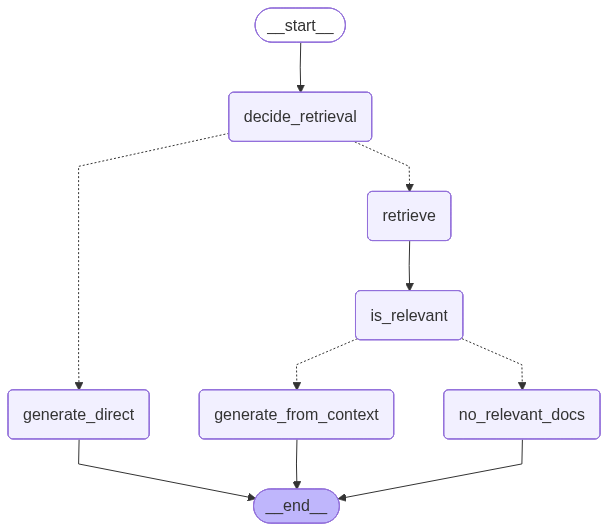

In [16]:
g = StateGraph(State)

g.add_node("decide_retrieval",decide_retrieval)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_relevant_docs",no_relevant_docs)

g.add_edge(START,"decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve",
    },
)

g.add_edge("generate_direct",END)
g.add_edge("retrieve","is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_docs":"no_relevant_docs"

    }
)

g.add_edge("generate_from_context",END)
g.add_edge("no_relevant_docs",END)

app = g.compile()

app

In [17]:
result = app.invoke({'question':"who is the ceo of NexaAI"})

In [18]:
print(result['answer'])

Aarav Mehta is the CEO of NexaAI.


In [19]:
result = app.invoke({'question':"who is the refund policy of NexaAI"})

In [20]:
print(result['answer'])

No relevant document found.
